In [1]:
import os
import qsprpred
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
X1 = pd.read_csv("hERG/mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("hERG/mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("hERG/mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("hERG/mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("hERG/mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("hERG/mod_data/y3.1", index_col="QSPRID")


In [3]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [4]:
y1.Y.sum()/y1.Y.count()

0.5832484725050916

In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,4668,4669,4670,4671,4672,4673,4674,4675,4676,4677
0,-0.368807,0.449969,-2.179742,0.533317,-0.305330,0.565028,1.694528,0.698365,-0.127115,0.181530,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.558479
1,-0.833699,0.984010,-2.094093,1.115777,-0.308247,1.050824,1.285909,0.619204,0.147659,0.597666,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.558479
2,0.718652,-1.241727,-1.294048,0.844113,-1.534152,0.413797,1.438163,-0.134257,0.650031,0.318751,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-1.138625
3,0.457665,-0.959587,-0.958390,0.952259,-1.395083,0.751934,1.598343,-0.201440,0.867544,1.090554,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.931042
4,-0.533496,0.466023,-1.137150,0.533591,-1.182542,0.407465,0.484916,0.602196,0.361761,0.971192,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.946793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9159,-1.372795,-0.408414,-0.269412,-0.296725,0.278256,-0.185780,-0.313672,-0.001844,0.525074,-0.587704,...,-0.223891,1.061998,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,0.403723
9160,-0.358796,-1.813513,-0.777799,-0.521747,0.828404,-0.579002,0.031730,1.028444,1.603450,-0.841053,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.608933
9161,-0.535688,1.280876,-0.035218,-0.665111,-1.151365,0.063225,-0.018170,-0.169370,0.120780,-0.797153,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,0.137063
9162,0.350739,0.666471,2.062234,-0.074140,1.242787,1.830375,-0.051098,-0.894747,-0.933312,-0.810303,...,-0.223891,3.422514,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,3.659017,1.138819


In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit(X1)


PCA(n_components=0.95)

In [7]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [8]:
n_components

1821

In [9]:
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

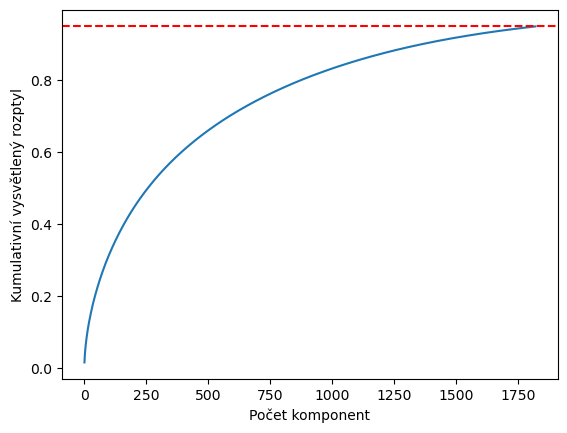

In [10]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [11]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/utils/validation.py:1229: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [12]:
pred = svc.predict(X2)

In [13]:
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score

print("Acc:", accuracy_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.7277369932971592
Mcc: 0.43326688049875306


In [ ]:
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
import pandas as pd
param_grid = ParameterGrid(param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],        # Regularizační parametr
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],   # Typ kernelu
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Parametr pro 'rbf', 'poly', 'sigmoid'
    'degree': [2, 3, 4, 5],                            # Relevantní pouze pro 'poly' kernel
    'coef0': [0.0, 0.1, 0.5, 1.0],                    # Relevantní pro 'poly', 'sigmoid'
 #   'shrinking': [True, False]                         # Použití strategie "shrinking" pro optimalizaci
}
)

val_mcc = []
val_f1 = []
val_acc = []
for param in tqdm(param_grid, total=len(param_grid)):
    svc = SVC(random_state=69, **param)
    svc.fit(X1, y1["Y"])
    pred_svc = svc.predict(X2)
    val_mcc.append(matthews_corrcoef(pred_svc, y2["Y"]))
    val_f1.append(f1_score(pred_svc, y2["Y"]))
    val_acc.append(accuracy_score(pred_svc, y2["Y"]))
    print("Params:", param, "\nMCC:", matthews_corrcoef(pred_svc, y2["Y"]))



  0%|                                         | 1/2688 [03:41<165:15:25, 221.41s/it]

Params: {'C': 0.001, 'coef0': 0.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'} 
MCC: 0.3817310399230347


  0%|                                         | 2/2688 [12:39<304:19:03, 407.87s/it]

Params: {'C': 0.001, 'coef0': 0.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'} 
MCC: 0.25357026851534725


  0%|                                         | 3/2688 [20:43<330:01:49, 442.50s/it]

...

Params: {'C': 0.001, 'coef0': 0.0, 'degree': 4, 'gamma': 1, 'kernel': 'rbf'} 
MCC: 0.0


  3%|█                                     | 71/2688 [7:26:22<164:54:01, 226.84s/it]

Params: {'C': 0.001, 'coef0': 0.0, 'degree': 4, 'gamma': 1, 'kernel': 'poly'} 
MCC: 0.24457053922518493


  3%|█                                     | 72/2688 [7:31:18<179:50:12, 247.48s/it]

Params: {'C': 0.001, 'coef0': 0.0, 'degree': 4, 'gamma': 1, 'kernel': 'sigmoid'} 
MCC: 0.2966114938436418


In [ ]:
svc_res = pd.DataFrame(param_grid)

In [ ]:
svc_res["mcc"] = val_mcc
svc_res["f1"] = val_f1
svc_res["acc"] = val_acc

In [ ]:
svc_res.sort_values(by=["mcc", "f1", "acc"], ascending=False, inplace=True)

In [ ]:
svc_res.to_csv("hERG/res/svc_res_val_1.1.csv")

In [ ]:
import numpy as np
best_params = param_grid[np.argmax(val_mcc)]

In [ ]:
best_params

In [ ]:
svc = SVC(**best_params)
svc.fit(X1, y1)

In [ ]:
pred = svc.predict(X2)

print("Acc:", accuracy_score(pred, y2))
print("F1:", f1_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

In [ ]:
pred_test = svc.predict(X3)

print("Acc:", accuracy_score(pred_test, y3))
print("F1:", f1_score(pred_test, y3))
print("Mcc:", matthews_corrcoef(pred_test, y3))

In [15]:
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_auc_score # Přidáme import pro ROC AUC
import pandas as pd
import optuna



def objective(trial, X_train, y_train, X_val, y_val):
    """Definice cílové funkce pro Optunu"""

    params = {
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid']),
        'C': trial.suggest_float('C', 0.00001, 1000),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
        'degree': trial.suggest_int('degree', 2, 5),
        'coef0': trial.suggest_float('coef0', 0, 1),
        'shrinking': trial.suggest_categorical('shrinking', [True, False]),
        'random_state': 69,  # Přidáno pro reprodukovatelnost
    }
    svc = SVC(random_state=69, **param)
    svc.fit(X_train, y_train["Y"])
    y_pred = svc.predict(X_val)
    mcc = matthews_corrcoef(y_val.Y, y_pred)  # Používáme MCC

    return mcc


In [ ]:
study = optuna.create_study(
    study_name="hERG_svm",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=1000
)
print("Best MCC:", study.best_value)
print("Best parameters:", study.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study.best_trial.user_attrs["f1"])
print("Best ACC:", study.best_trial.user_attrs["acc"])

[I 2025-05-18 23:31:00,728] A new study created in RDB with name: hERG_svm
